In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')



In [3]:
matches    = pd.read_csv('ipl_matches.csv')
deliveries = pd.read_csv('ipl_deliveries.csv')

print("Matches shape    :", matches.shape)
print("Deliveries shape :", deliveries.shape)

Matches shape    : (1029, 16)
Deliveries shape : (242047, 22)


In [4]:
matches.head(5)

,match_id,season,city,date,team1,team2,toss_winner,toss_decision,result,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2008,Chennai,2008-04-06,Rajasthan Royals,Mumbai Indians,Mumbai Indians,bat,normal,Rajasthan Royals,53,0,Player_130,"Feroz Shah Kotla, Delhi",Umpire_1,Umpire_12
1,2,2008,Kolkata,2008-05-20,Chennai Super Kings,Punjab Kings,Punjab Kings,bat,no result,NaN,0,0,Player_64,"Narendra Modi Stadium, Ahmedabad",Umpire_3,Umpire_5
2,3,2008,Hyderabad,2008-03-08,Punjab Kings,Lucknow Super Giants,Lucknow Super Giants,bat,normal,Punjab Kings,60,0,Player_175,"Eden Gardens, Kolkata",Umpire_14,Umpire_17
3,4,2008,Chandigarh,2008-04-23,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,field,normal,Royal Challengers Bangalore,0,4,Player_190,"PCA Stadium, Chandigarh",Umpire_21,Umpire_16
4,5,2008,Mumbai,2008-05-11,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,field,normal,Sunrisers Hyderabad,88,0,Player_81,"PCA Stadium, Chandigarh",Umpire_3,Umpire_3


In [5]:
deliveries.head(5)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,is_wicket,player_dismissed,dismissal_kind,fielder
0,1,1,Rajasthan Royals,Mumbai Indians,0,1,Batsman_103,Batsman_41,Bowler_36,0,...,0,0,0,0,1,1,0,NaN,NaN,NaN
1,1,1,Rajasthan Royals,Mumbai Indians,0,2,Batsman_88,Batsman_111,Bowler_18,0,...,0,0,0,1,0,1,0,NaN,NaN,NaN
2,1,1,Rajasthan Royals,Mumbai Indians,0,3,Batsman_35,Batsman_15,Bowler_6,0,...,0,0,0,1,0,1,0,NaN,NaN,NaN
3,1,1,Rajasthan Royals,Mumbai Indians,0,4,Batsman_5,Batsman_45,Bowler_64,0,...,0,0,0,4,0,4,0,NaN,NaN,NaN
4,1,1,Rajasthan Royals,Mumbai Indians,0,5,Batsman_13,Batsman_113,Bowler_3,0,...,0,0,0,1,0,1,0,NaN,NaN,NaN


In [6]:
print("=== MATCHES INFO ===")
matches.info()

=== MATCHES INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1029 entries, 0 to 1028
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   match_id         1029 non-null   int64
 1   season           1029 non-null   int64
 2   city             1029 non-null   str  
 3   date             1029 non-null   str  
 4   team1            1029 non-null   str  
 5   team2            1029 non-null   str  
 6   toss_winner      1029 non-null   str  
 7   toss_decision    1029 non-null   str  
 8   result           1029 non-null   str  
 9   winner           989 non-null    str  
 10  win_by_runs      1029 non-null   int64
 11  win_by_wickets   1029 non-null   int64
 12  player_of_match  1029 non-null   str  
 13  venue            1029 non-null   str  
 14  umpire1          1029 non-null   str  
 15  umpire2          1029 non-null   str  
dtypes: int64(4), str(12)
memory usage: 283.3 KB


In [7]:
print("=== DELIVERIES INFO ===")
deliveries.info()

=== DELIVERIES INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 242047 entries, 0 to 242046
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          242047 non-null  int64
 1   inning            242047 non-null  int64
 2   batting_team      242047 non-null  str  
 3   bowling_team      242047 non-null  str  
 4   over              242047 non-null  int64
 5   ball              242047 non-null  int64
 6   batsman           242047 non-null  str  
 7   non_striker       242047 non-null  str  
 8   bowler            242047 non-null  str  
 9   is_super_over     242047 non-null  int64
 10  wide_runs         242047 non-null  int64
 11  bye_runs          242047 non-null  int64
 12  legbye_runs       242047 non-null  int64
 13  noball_runs       242047 non-null  int64
 14  penalty_runs      242047 non-null  int64
 15  batsman_runs      242047 non-null  int64
 16  extra_runs        242047 non-null  int64
 1

In [8]:
matches.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
match_id,1029.0,NaN,NaN,NaN,515.0,297.191016,1.0,258.0,515.0,772.0,1029.0
season,1029.0,NaN,NaN,NaN,2015.547133,4.597936,2008.0,2012.0,2016.0,2019.0,2023.0
city,1029,10,Lucknow,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,1029,711,2019-04-02,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1,1029,10,Kolkata Knight Riders,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,1029,10,Gujarat Titans,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,1029,10,Lucknow Super Giants,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_decision,1029,2,field,670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
result,1029,2,normal,989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
winner,989,10,Sunrisers Hyderabad,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print("--- Matches Missing Values ---")
m_miss = matches.isnull().sum()
print(m_miss[m_miss > 0])

print("\n--- Deliveries Missing Values ---")
d_miss = deliveries.isnull().sum()
print(d_miss[d_miss > 0])

--- Matches Missing Values ---
winner    40
dtype: int64

--- Deliveries Missing Values ---
player_dismissed    228625
dismissal_kind      228625
fielder             235446
dtype: int64


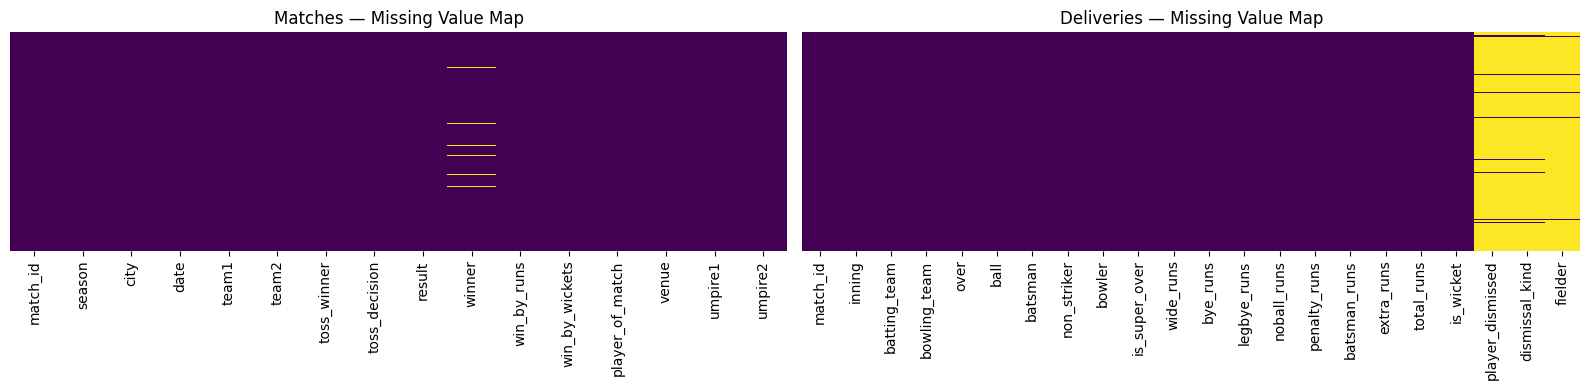

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.heatmap(matches.isnull(), yticklabels=False, cbar=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Matches — Missing Value Map', fontsize=12)

sns.heatmap(deliveries.isnull(), yticklabels=False, cbar=False,
            cmap='viridis', ax=axes[1])
axes[1].set_title('Deliveries — Missing Value Map', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Fill missing winner with 'No Result'
matches['winner'] = matches['winner'].fillna('No Result')

# Fill empty string dismissal with 'not out'
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].replace('', 'not out')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('not out')

# Fix date column
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Duplicates check
print(f"Duplicate rows (matches)    : {matches.duplicated().sum()}")
print(f"Duplicate rows (deliveries) : {deliveries.duplicated().sum()}")

print("\n✅ Cleaning done!")
print(f"Matches nulls left    : {matches.isnull().sum().sum()}")
print(f"Deliveries nulls left : {deliveries.isnull().sum().sum()}")

Duplicate rows (matches)    : 0
Duplicate rows (deliveries) : 0

✅ Cleaning done!
Matches nulls left    : 0
Deliveries nulls left : 464071


In [12]:
# Total runs per match per team
match_scores = (deliveries.groupby(['match_id','batting_team'])['total_runs']
                .sum().reset_index())
match_scores.columns = ['match_id','batting_team','innings_score']

# Win counts per team
win_counts = (matches[matches['winner'] != 'No Result']['winner']
              .value_counts().reset_index())
win_counts.columns = ['team','wins']

# Season-wise matches
season_matches = matches.groupby('season').size().reset_index(name='total_matches')

# Toss win → match win rate
valid = matches[matches['winner'] != 'No Result']
toss_rate = (valid['winner'] == valid['toss_winner']).mean() * 100

# Top batsmen
top_batsmen = (deliveries.groupby('batsman')['batsman_runs']
               .sum().reset_index()
               .sort_values('batsman_runs', ascending=False).head(15))

# Top bowlers
top_bowlers = (deliveries[deliveries['is_wicket'] == 1]
               .groupby('bowler')['is_wicket'].count().reset_index()
               .rename(columns={'is_wicket':'wickets'})
               .sort_values('wickets', ascending=False).head(15))

# Over-wise avg runs
over_runs = deliveries.groupby('over')['total_runs'].mean().reset_index()

# Dismissal types
dismissals = (deliveries[deliveries['dismissal_kind'] != 'not out']
              ['dismissal_kind'].value_counts())

print(f"Toss → Win rate : {toss_rate:.1f}%")
print(f"Top team wins   : {win_counts.iloc[0]['team']} ({win_counts.iloc[0]['wins']} wins)")
print("\n✅ Feature engineering done!")

Toss → Win rate : 49.4%
Top team wins   : Sunrisers Hyderabad (110 wins)

✅ Feature engineering done!


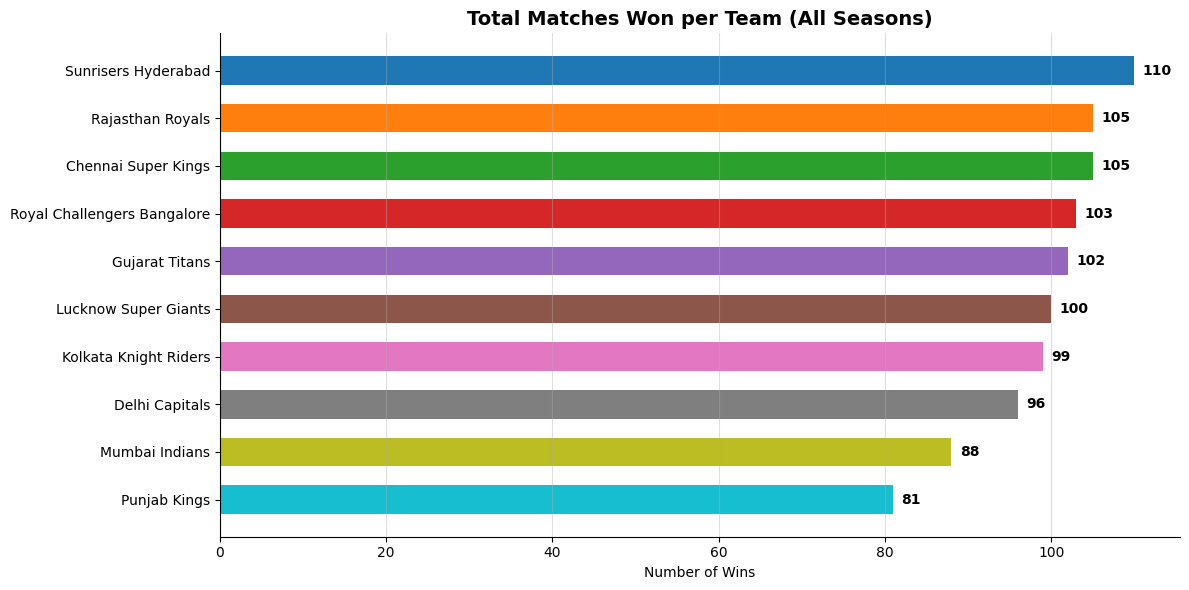

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = cm.tab10(np.linspace(0, 1, len(win_counts)))
bars = ax.barh(win_counts['team'], win_counts['wins'], color=colors, height=0.6)
for bar, val in zip(bars, win_counts['wins']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')
ax.set_title('Total Matches Won per Team (All Seasons)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Wins')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

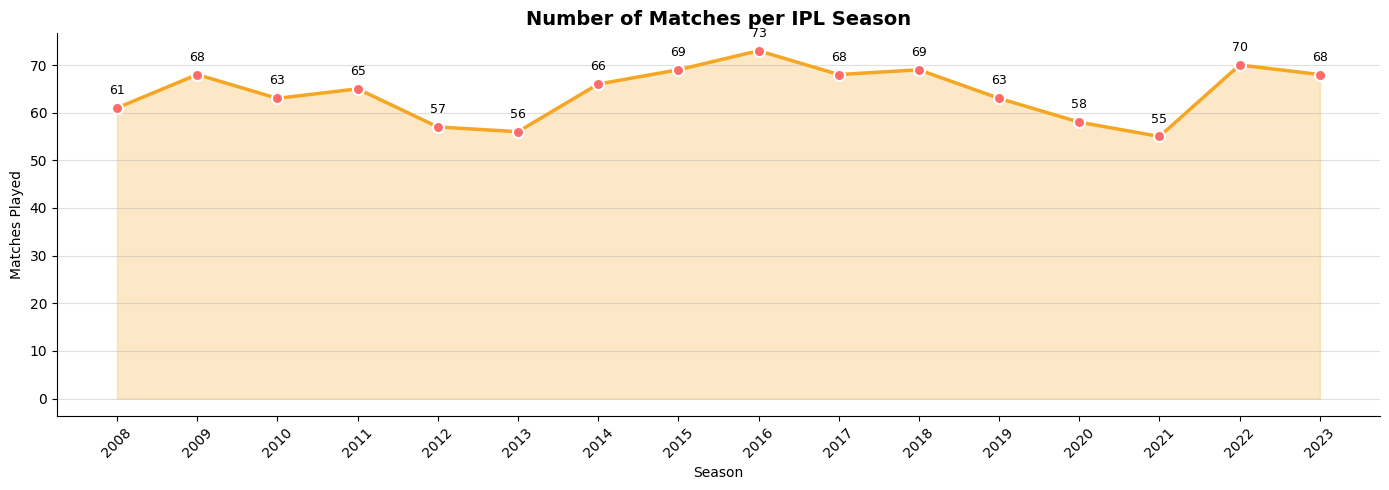

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(season_matches['season'], season_matches['total_matches'],
                alpha=0.25, color='#f5a623')
ax.plot(season_matches['season'], season_matches['total_matches'],
        color='#f5a623', linewidth=2.5, marker='o', markersize=8,
        markerfacecolor='#ff6b6b', markeredgecolor='white', markeredgewidth=1.5)
for x, y in zip(season_matches['season'], season_matches['total_matches']):
    ax.annotate(str(y), (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
ax.set_title('Number of Matches per IPL Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Matches Played')
ax.set_xticks(season_matches['season'])
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

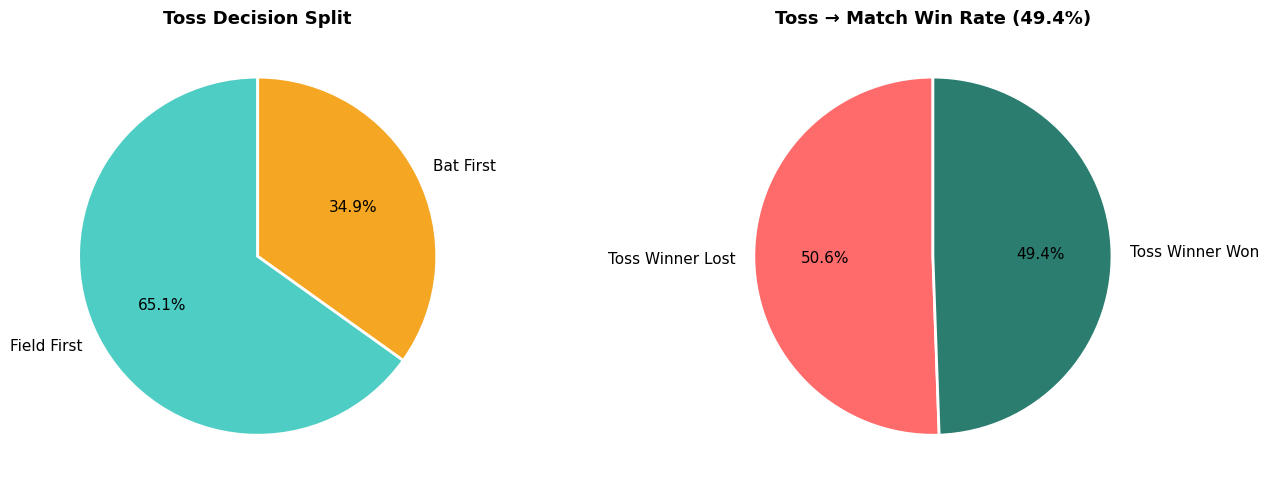

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Toss decision split
td = matches['toss_decision'].value_counts()
axes[0].pie(td.values, labels=['Field First', 'Bat First'],
            autopct='%1.1f%%', colors=['#4ecdc4','#f5a623'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops=dict(fontsize=11))
axes[0].set_title('Toss Decision Split', fontsize=13, fontweight='bold')

# Toss winner vs match winner
toss_labels = ['Toss Winner Lost', 'Toss Winner Won']
toss_vals   = [100 - toss_rate, toss_rate]
axes[1].pie(toss_vals, labels=toss_labels, autopct='%1.1f%%',
            colors=['#ff6b6b','#2a7d6f'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops=dict(fontsize=11))
axes[1].set_title(f'Toss → Match Win Rate ({toss_rate:.1f}%)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

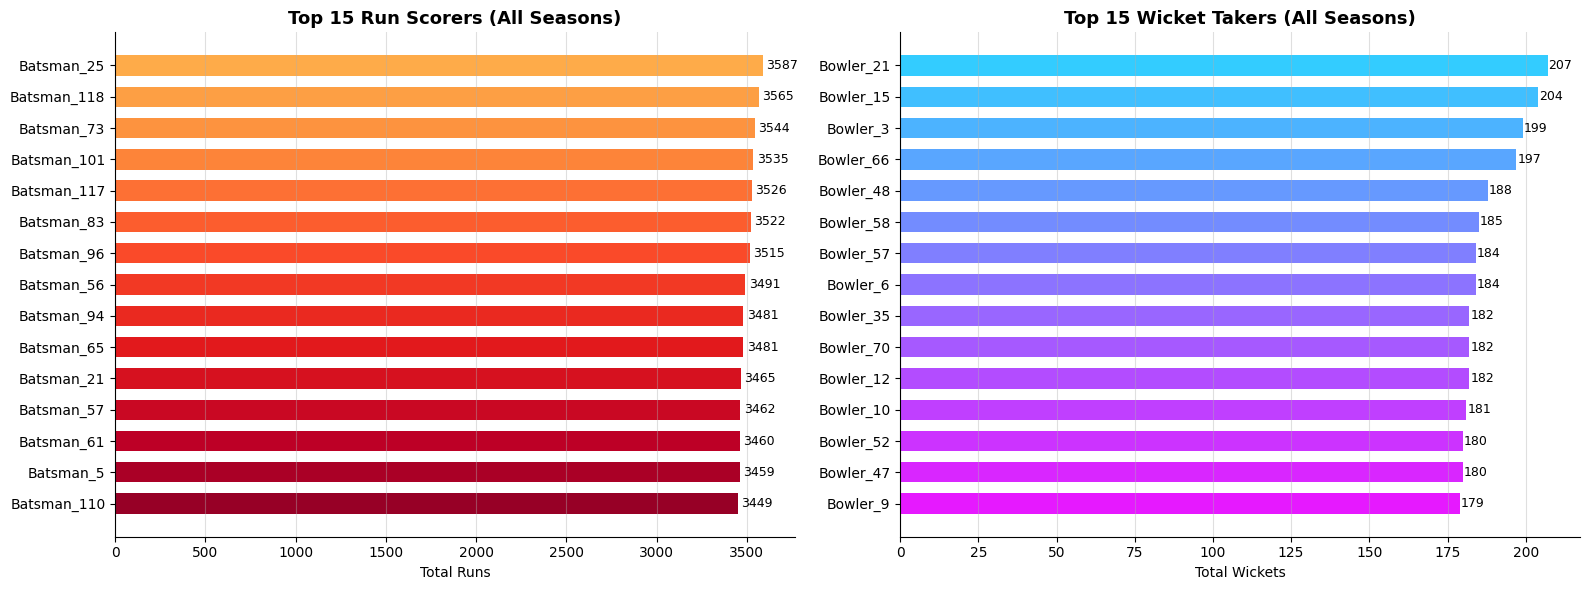

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Batsmen
cols1 = cm.YlOrRd(np.linspace(0.4, 0.95, len(top_batsmen)))
axes[0].barh(top_batsmen['batsman'], top_batsmen['batsman_runs'],
             color=cols1, height=0.65)
for i, (_, row) in enumerate(top_batsmen.iterrows()):
    axes[0].text(row['batsman_runs'] + 20, i,
                 str(row['batsman_runs']), va='center', fontsize=9)
axes[0].set_title('Top 15 Run Scorers (All Seasons)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Runs')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.4)
axes[0].spines[['top','right']].set_visible(False)

# Top Bowlers
cols2 = cm.cool(np.linspace(0.2, 0.9, len(top_bowlers)))
axes[1].barh(top_bowlers['bowler'], top_bowlers['wickets'],
             color=cols2, height=0.65)
for i, (_, row) in enumerate(top_bowlers.iterrows()):
    axes[1].text(row['wickets'] + 0.3, i,
                 str(row['wickets']), va='center', fontsize=9)
axes[1].set_title('Top 15 Wicket Takers (All Seasons)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Wickets')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.4)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

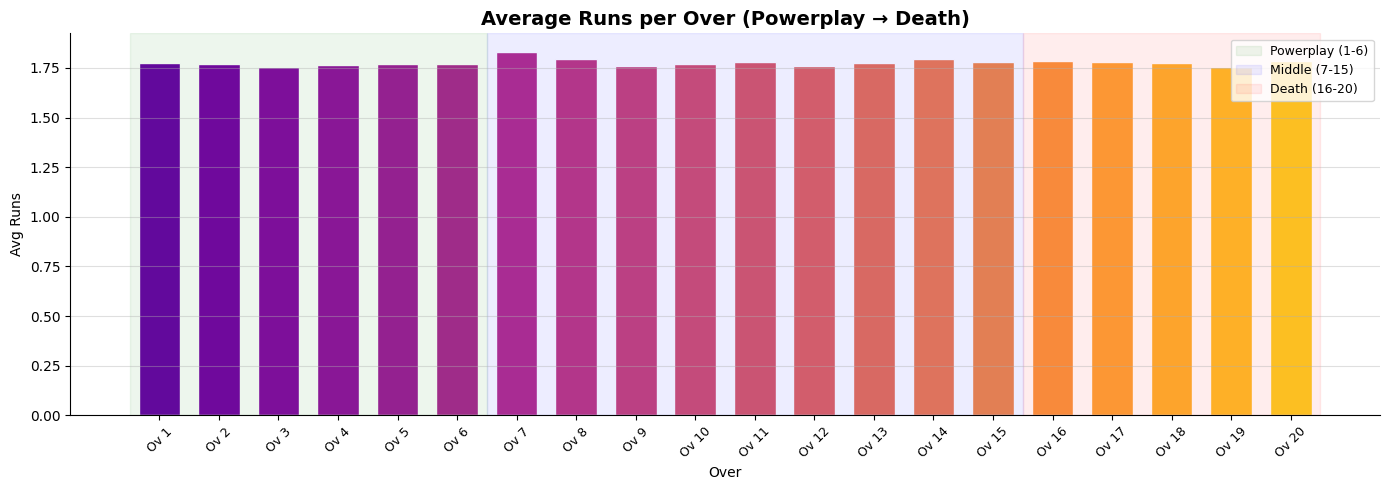

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
colors_ov = cm.plasma(np.linspace(0.2, 0.9, 20))
bars = ax.bar(over_runs['over'], over_runs['total_runs'],
              color=colors_ov, edgecolor='white', width=0.7)
ax.set_xticks(range(20))
ax.set_xticklabels([f"Ov {i+1}" for i in range(20)], rotation=45, fontsize=9)
ax.set_title('Average Runs per Over (Powerplay → Death)', fontsize=14, fontweight='bold')
ax.set_xlabel('Over')
ax.set_ylabel('Avg Runs')

# Powerplay / middle / death shading
ax.axvspan(-0.5, 5.5, alpha=0.07, color='green', label='Powerplay (1-6)')
ax.axvspan(5.5, 14.5, alpha=0.07, color='blue',  label='Middle (7-15)')
ax.axvspan(14.5, 19.5, alpha=0.07, color='red',  label='Death (16-20)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

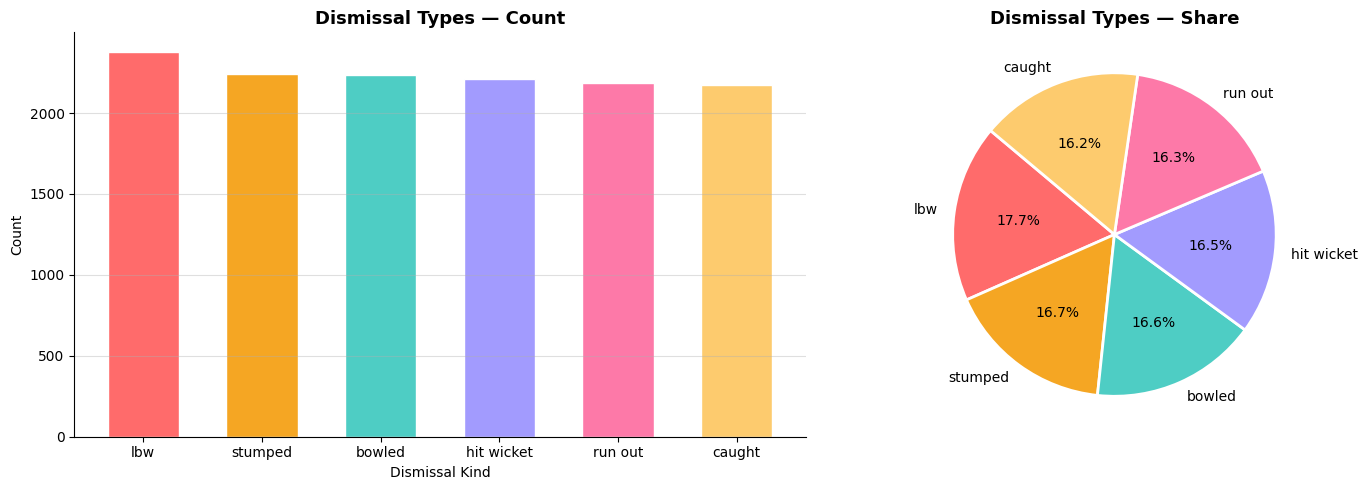

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
d_vals = dismissals.head(6)
bar_colors = ['#ff6b6b','#f5a623','#4ecdc4','#a29bfe','#fd79a8','#fdcb6e']
axes[0].bar(d_vals.index, d_vals.values, color=bar_colors, edgecolor='white', width=0.6)
axes[0].set_title('Dismissal Types — Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dismissal Kind')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines[['top','right']].set_visible(False)

# Pie
axes[1].pie(d_vals.values, labels=d_vals.index, autopct='%1.1f%%',
            colors=bar_colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Dismissal Types — Share', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

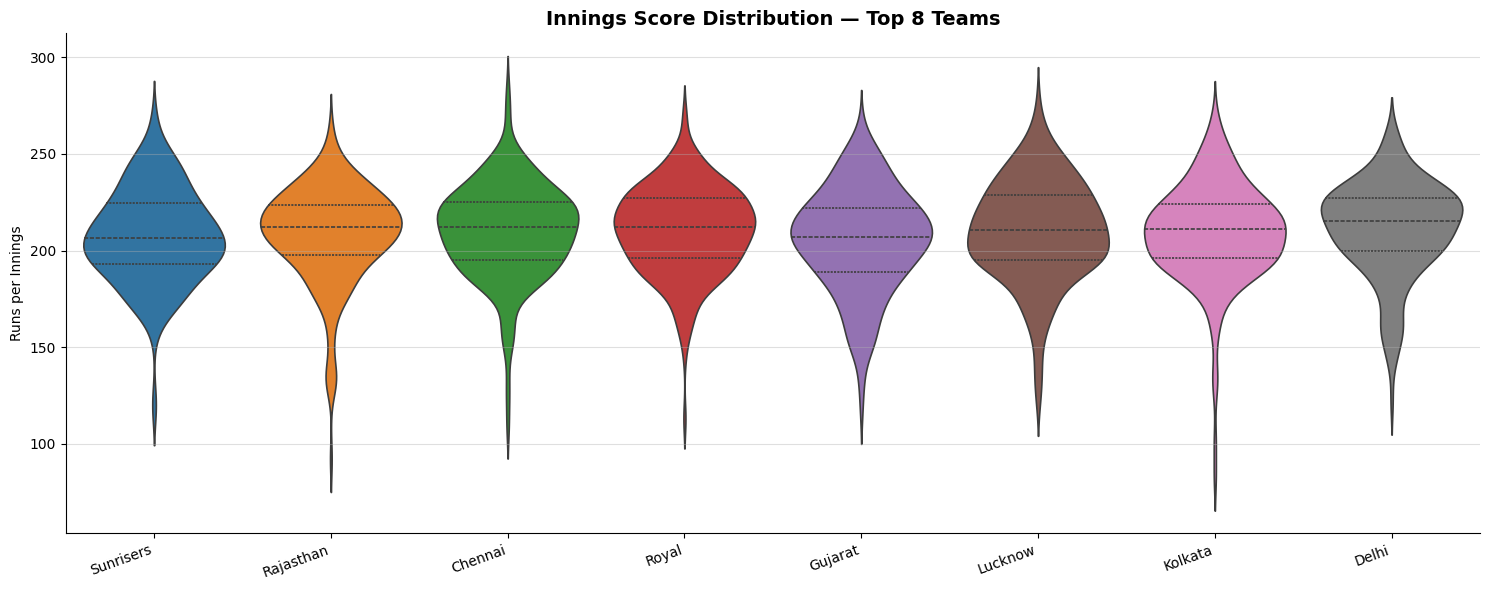

In [19]:
teams_list = win_counts['team'].head(8).tolist()
ms_top = match_scores[match_scores['batting_team'].isin(teams_list)]

fig, ax = plt.subplots(figsize=(15, 6))
sns.violinplot(data=ms_top, x='batting_team', y='innings_score',
               palette='tab10', inner='quartile', linewidth=1.2,
               density_norm='width', ax=ax)
ax.set_xticklabels([t.split()[0] for t in teams_list], rotation=20, ha='right')
ax.set_title('Innings Score Distribution — Top 8 Teams', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Runs per Innings')
ax.grid(axis='y', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

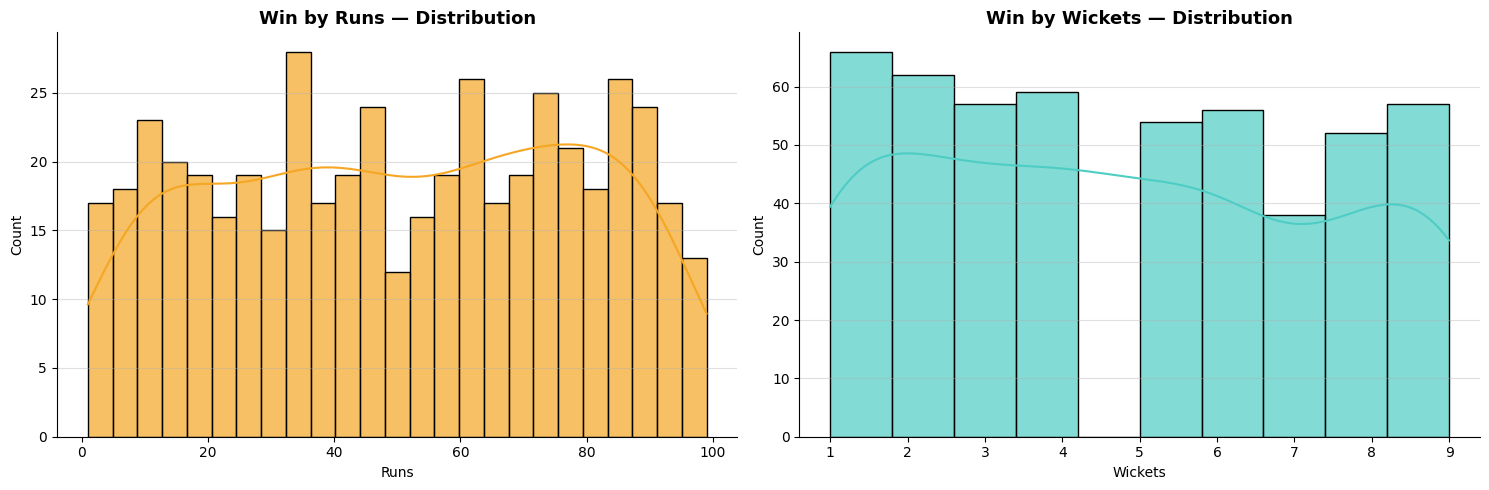

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

wbr = matches[matches['win_by_runs'] > 0]['win_by_runs']
wbw = matches[matches['win_by_wickets'] > 0]['win_by_wickets']

sns.histplot(wbr, bins=25, color='#f5a623', alpha=0.7, kde=True, ax=axes[0])
axes[0].set_title('Win by Runs — Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Runs')
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines[['top','right']].set_visible(False)

sns.histplot(wbw, bins=10, color='#4ecdc4', alpha=0.7, kde=True, ax=axes[1])
axes[1].set_title('Win by Wickets — Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Wickets')
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

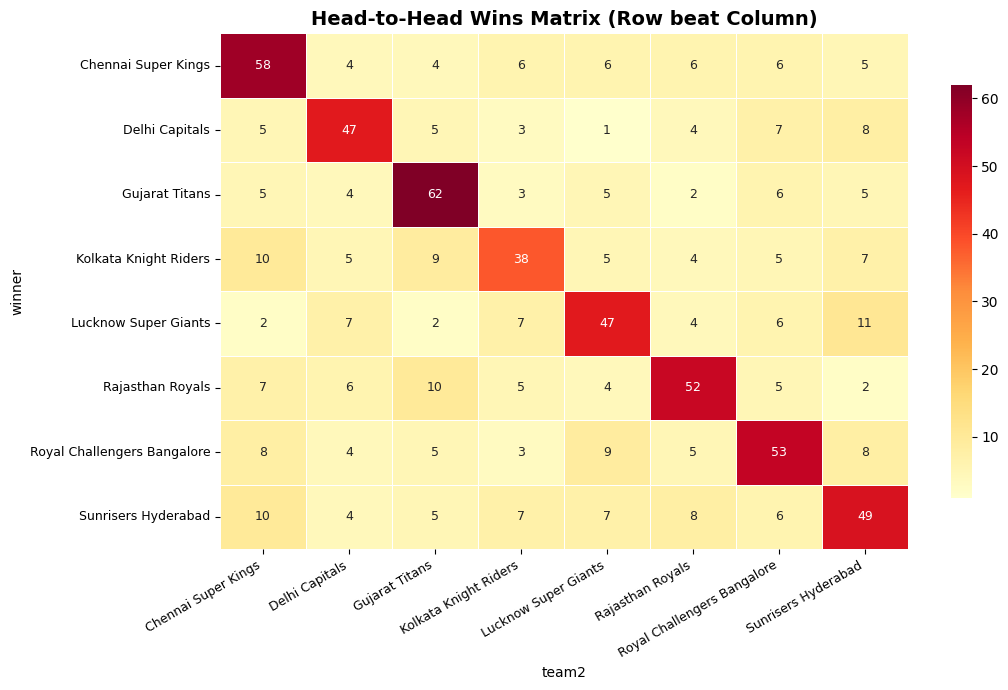

In [21]:
h2h = pd.crosstab(matches['winner'], matches['team2'])
h2h = h2h.loc[h2h.index.isin(win_counts['team'].head(8)),
               h2h.columns.isin(win_counts['team'].head(8))]

plt.figure(figsize=(11, 7))
sns.heatmap(h2h, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
plt.title('Head-to-Head Wins Matrix (Row beat Column)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

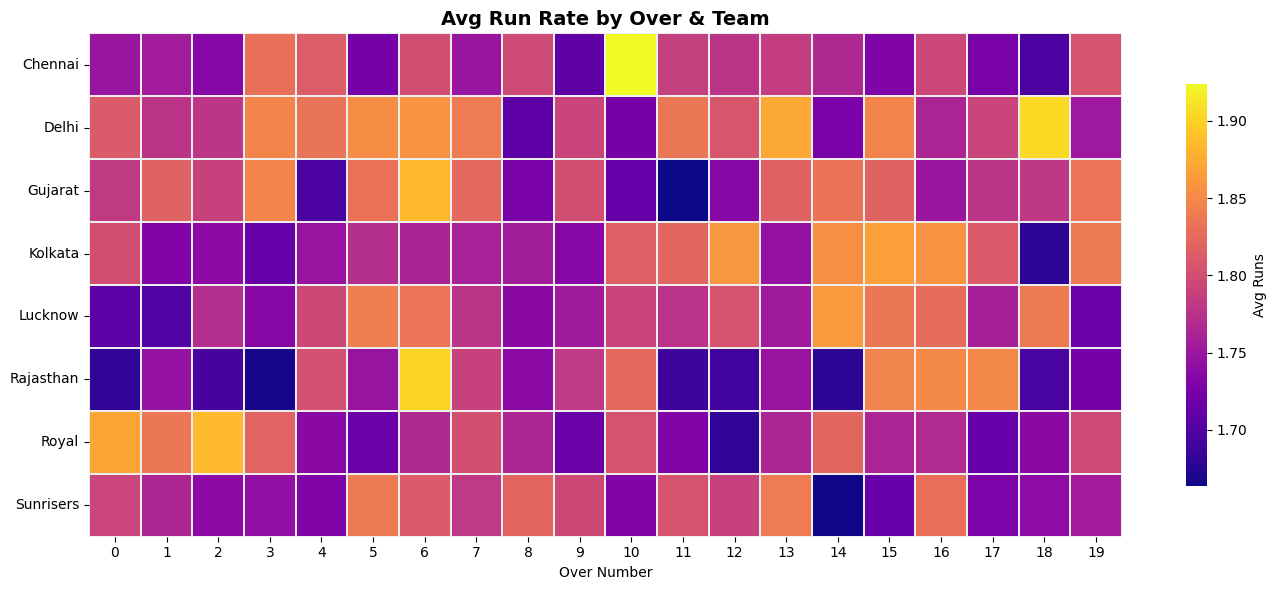

In [22]:
teams8 = win_counts['team'].head(8).tolist()
ot = (deliveries[deliveries['batting_team'].isin(teams8)]
      .groupby(['over','batting_team'])['total_runs'].mean().unstack())
ot.columns = [c.split()[0] for c in ot.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(ot.T, cmap='plasma', linewidths=0.3, linecolor='#eee',
            cbar_kws={'shrink': 0.8, 'label': 'Avg Runs'})
plt.title('Avg Run Rate by Over & Team', fontsize=14, fontweight='bold')
plt.xlabel('Over Number')
plt.ylabel('')
plt.tight_layout()
plt.show()

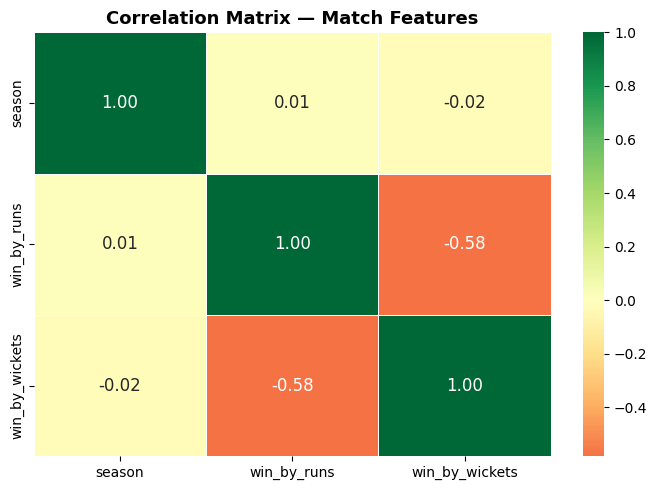

In [23]:
num_cols = ['season','win_by_runs','win_by_wickets']
corr = matches[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size':12})
plt.title('Correlation Matrix — Match Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
matches.to_csv('ipl_matches_cleaned.csv', index=False)
print(f"✅ Saved: ipl_matches_cleaned.csv  — {matches.shape}")

# Save match scores
match_scores.to_csv('ipl_match_scores.csv', index=False)
print(f"✅ Saved: ipl_match_scores.csv     — {match_scores.shape}")

✅ Saved: ipl_matches_cleaned.csv  — (1029, 16)
✅ Saved: ipl_match_scores.csv     — (2058, 3)
